In [33]:
# Cell 1: imports + paths + globals
import time, random, numpy as np, pandas as pd
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt, seaborn as sns

# Paths (adjust if needed)
PROJECT_ROOT = Path("/Users/syedadnanahmad/Downloads/AI_TUMOUR_detection")
EMB_ROOT     = PROJECT_ROOT / "embeddings"
IDX_CSV      = PROJECT_ROOT / "notebooks" / "slide_index.csv"
MODEL_DIR    = PROJECT_ROOT / "models"
RESULTS_DIR  = PROJECT_ROOT / "results"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Device:", device)

# Load index & classes
df_index = pd.read_csv(IDX_CSV)
OSCC_CLASSES = ["wdoscc","mdoscc","pdoscc"]
classes = OSCC_CLASSES.copy()
num_classes = len(classes)
K = 20  # bag size 
print("Num slides total:", len(df_index), "OSCC classes:", classes, "K=", K)


Device: mps
Num slides total: 448 OSCC classes: ['wdoscc', 'mdoscc', 'pdoscc'] K= 20


In [37]:
# Cell 2: Dataset — samples K patches per slide; oversamples PD for train split
import numpy as np

class OSCC_Subtype_Dataset(Dataset):
    def __init__(self, df, split, k=K, oversample_pd_copies=1):
        self.split = split
        self.k = k
        rows = df[(df["split"]==split) & (df["class"].isin(OSCC_CLASSES))].reset_index(drop=True)
        self.items = []
        for _, r in rows.iterrows():
            slide = r["slide_id"]; cls = r["class"]
            emb_path = EMB_ROOT / split / cls / f"{slide}.npy"
            if emb_path.exists():
                self.items.append({"emb_path": emb_path, "label": OSCC_CLASSES.index(cls), "slide_id": slide})
        assert len(self.items) > 0, f"No OSCC items for split={split}"
        # oversample PD only for training set by duplicating entries
        if split == "train" and oversample_pd_copies > 0:
            pd_idx = OSCC_CLASSES.index("pdoscc")
            extra = []
            for it in list(self.items):
                if it["label"] == pd_idx:
                    for _ in range(oversample_pd_copies):
                        extra.append(it.copy())
            self.items.extend(extra)
            random.shuffle(self.items)

    def __len__(self): 
        return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        arr = np.load(it["emb_path"]).astype(np.float32)   # (N,D)
        n = arr.shape[0]
        if n >= self.k:
            sel = np.random.choice(n, self.k, replace=False)
        else:
            sel = np.random.choice(n, self.k, replace=True)
        sampled = torch.from_numpy(arr[sel])   # (K, D)
        label = torch.tensor(it["label"], dtype=torch.long)
        return {"emb": sampled, "label": label, "slide_id": it["slide_id"]}


In [38]:
# Cell 3: instantiate datasets & dataloaders
train_ds = OSCC_Subtype_Dataset(df_index, "train", k=K, oversample_pd_copies=1)
val_ds   = OSCC_Subtype_Dataset(df_index, "val",   k=K, oversample_pd_copies=0)
test_ds  = OSCC_Subtype_Dataset(df_index, "test",  k=K, oversample_pd_copies=0)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=lambda x: x[0], num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=lambda x: x[0], num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=lambda x: x[0], num_workers=0)

print("Train slides (after oversample):", len(train_ds))
print("Val slides:", len(val_ds))
print("Test slides:", len(test_ds))

# quick class counts (train)
from collections import Counter
train_labels = [it["label"] for it in train_ds.items]
print("Train label counts (post-oversample):", Counter(train_labels))


Train slides (after oversample): 123
Val slides: 104
Test slides: 105
Train label counts (post-oversample): Counter({0: 44, 1: 41, 2: 38})


In [39]:
# Cell 4: TopK Attention MIL (multi-class)
class TopK_AttentionMIL(nn.Module):
    def __init__(self, emb_dim=512, hidden_dim=512, num_classes=3, k=K):
        super().__init__()
        self.k = k
        self.V = nn.Linear(emb_dim, hidden_dim)
        self.U = nn.Linear(emb_dim, hidden_dim)
        self.w = nn.Linear(hidden_dim, 1)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim//2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(emb_dim//2, num_classes)
        )

    def forward(self, H):
        # H: (K, D)
        Vh = torch.tanh(self.V(H))
        Uh = torch.sigmoid(self.U(H))
        A = self.w(Vh * Uh).squeeze(1)    # (K,)
        # select top-K by attention value
        Ksel = min(self.k, H.shape[0])
        top_vals, top_idx = torch.topk(A, Ksel)
        H_top = H[top_idx]                # (Ksel, D)
        A_top = torch.softmax(top_vals, dim=0)   # (Ksel,)
        agg = torch.sum(A_top.unsqueeze(1) * H_top, dim=0)
        logits = self.classifier(agg)
        return logits.unsqueeze(0), A_top, top_idx


In [44]:
# Cell 5: Focal Loss + model instantiation + optimizer
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        if alpha is None:
            self.alpha = None
        else:
            self.alpha = torch.tensor(alpha, dtype=torch.float32).to(device)
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        probs = F.softmax(logits, dim=1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        loss = ce * (1 - pt) ** self.gamma
        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            loss = loss * at
        return loss.mean() if self.reduction == 'mean' else loss.sum()

# instantiate model + optimizer
model = TopK_AttentionMIL(emb_dim=512, hidden_dim=512, num_classes=num_classes, k=K).to(device)
# PD upweight (index 2)
alpha = torch.tensor([1.0, 1.0, 1.0], dtype=torch.float32).to(device)
criterion = FocalLoss(gamma=2.0, alpha=alpha)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-5)
print("Model params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Model params: 657924


/var/folders/sf/m51mp7kn7773_zbvjf21qbph0000gn/T/ipykernel_4495/918922857.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.alpha = torch.tensor(alpha, dtype=torch.float32).to(device)


In [45]:
# Cell 6: train/validate helper functions
import numpy as np

def train_epoch(model, loader, optimizer):
    model.train()
    losses, y_true, y_pred = [], [], []
    for b in loader:
        emb = b["emb"].to(device)     # (K, D)
        label = b["label"].to(device)
        optimizer.zero_grad()
        logits, attn, idx = model(emb)
        loss = criterion(logits, label.unsqueeze(0))
        loss.backward(); optimizer.step()
        losses.append(loss.item())
        probs = F.softmax(logits, dim=1).detach().cpu().numpy()[0]
        y_pred.append(int(np.argmax(probs))); y_true.append(int(label))
    return np.mean(losses), np.array(y_true), np.array(y_pred)

def validate_epoch(model, loader):
    model.eval()
    losses, y_true, y_pred, y_scores = [], [], [], []
    with torch.no_grad():
        for b in loader:
            emb = b["emb"].to(device)
            label = b["label"].to(device)
            logits, attn, idx = model(emb)
            loss = criterion(logits, label.unsqueeze(0)); losses.append(loss.item())
            probs = F.softmax(logits, dim=1).cpu().numpy()[0]
            y_scores.append(probs); y_pred.append(int(np.argmax(probs))); y_true.append(int(label))
    return np.mean(losses), np.array(y_true), np.array(y_pred), np.vstack(y_scores)


In [46]:
# Cell 7: training loop with scheduler, checkpointing
from sklearn.metrics import precision_recall_fscore_support
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
best = -1.0; patience = 8; no_imp = 0; EPOCHS = 40

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_y, tr_pred = train_epoch(model, train_loader, optimizer)
    va_loss, va_y, va_pred, va_scores = validate_epoch(model, val_loader)
    _, _, f1s, _ = precision_recall_fscore_support(va_y, va_pred, labels=list(range(num_classes)), zero_division=0)
    macro_f1 = float(np.mean(f1s))
    acc = accuracy_score(va_y, va_pred)
    print(f"Epoch {epoch}: val_macro_f1={macro_f1:.4f} val_acc={acc:.4f} time={(time.time()-t0):.1f}s")
    scheduler.step(macro_f1)
    if macro_f1 > best:
        best = macro_f1; no_imp = 0
        torch.save({"model_state":model.state_dict(),"epoch":epoch,"val_macro_f1":best}, MODEL_DIR/f"oscc_topkK{K}_best.pth")
        print("Saved best (epoch", epoch, "f1", best, ")")
    # else:
    #     no_imp += 1
    #     if no_imp >= patience:
    #         print("Early stopping. No improvement for", patience, "epochs.")
    #         break


Epoch 1: val_macro_f1=0.2804 val_acc=0.4519 time=1.0s
Saved best (epoch 1 f1 0.2803846718543533 )
Epoch 2: val_macro_f1=0.2896 val_acc=0.4519 time=1.1s
Saved best (epoch 2 f1 0.28956521739130436 )
Epoch 3: val_macro_f1=0.3952 val_acc=0.4808 time=1.0s
Saved best (epoch 3 f1 0.39515893846602507 )
Epoch 4: val_macro_f1=0.4585 val_acc=0.5192 time=0.9s
Saved best (epoch 4 f1 0.45845424836601306 )
Epoch 5: val_macro_f1=0.5057 val_acc=0.5385 time=0.9s
Saved best (epoch 5 f1 0.5057191317784538 )
Epoch 6: val_macro_f1=0.4986 val_acc=0.5481 time=0.9s
Epoch 7: val_macro_f1=0.6027 val_acc=0.6154 time=0.8s
Saved best (epoch 7 f1 0.6027232027232027 )
Epoch 8: val_macro_f1=0.5165 val_acc=0.5481 time=0.8s
Epoch 9: val_macro_f1=0.5572 val_acc=0.5673 time=0.9s
Epoch 10: val_macro_f1=0.5571 val_acc=0.5769 time=0.8s
Epoch 11: val_macro_f1=0.6076 val_acc=0.6154 time=0.8s
Saved best (epoch 11 f1 0.6076266541382821 )
Epoch 12: val_macro_f1=0.5984 val_acc=0.6058 time=0.8s
Epoch 13: val_macro_f1=0.5859 val_acc

Test loss: 0.3684044946517263
=== Classification report ===
              precision    recall  f1-score   support

      wdoscc       0.65      0.68      0.67        44
      mdoscc       0.61      0.45      0.52        42
      pdoscc       0.50      0.74      0.60        19

    accuracy                           0.60       105
   macro avg       0.59      0.62      0.59       105
weighted avg       0.61      0.60      0.60       105

Confusion matrix:
 [[30  9  5]
 [14 19  9]
 [ 2  3 14]]


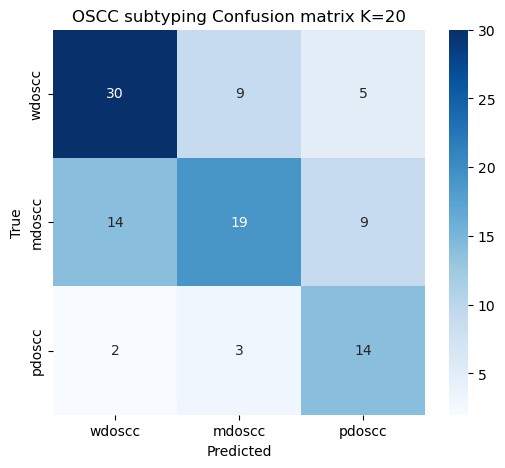

In [47]:
# Cell 8: load best model and evaluate on test set
ck = torch.load(MODEL_DIR/f"oscc_topkK{K}_best.pth", map_location=device)
model.load_state_dict(ck["model_state"]); model.to(device); model.eval()

te_loss, te_y, te_pred, te_scores = validate_epoch(model, test_loader)
print("Test loss:", te_loss)
print("=== Classification report ===")
print(classification_report(te_y, te_pred, target_names=classes, zero_division=0))
cm = confusion_matrix(te_y, te_pred, labels=list(range(num_classes)))
print("Confusion matrix:\n", cm)

# plot & save
plt.figure(figsize=(6,5)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"OSCC subtyping Confusion matrix K={K}")
plt.savefig(RESULTS_DIR/f"oscc_cm_K{K}.png", bbox_inches='tight'); plt.show()
